<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# 📊 Visualización de Datos — Matplotlib & Seaborn
### Taller de Programación

---

| Librería | Descripción |
|---|---|
| **Matplotlib** | Base de casi toda la visualización en Python. Control total sobre cada elemento. |
| **Seaborn** | Construida sobre Matplotlib. Menos código, estilos más prolijos, integración directa con DataFrames. |

En cada sección vamos a resolver **el mismo gráfico** con ambas librerías para comparar el código.

### Dataset
Datos sintéticos de ventas: 3 regiones × 4 productos × 12 meses (2026).

---
## 0. Setup y dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi']         = 110
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
sns.set_theme(style='whitegrid', palette='tab10')

np.random.seed(42)

MESES     = ['Ene','Feb','Mar','Abr','May','Jun',
              'Jul','Ago','Sep','Oct','Nov','Dic']
REGIONES  = ['Norte', 'Centro', 'Sur']
PRODUCTOS = ['Laptop', 'Monitor', 'Teclado', 'Mouse']
PRECIO    = {'Laptop': 1200, 'Monitor': 400, 'Teclado': 80, 'Mouse': 35}

filas = []
for mes_idx, mes in enumerate(MESES):
    for region in REGIONES:
        for producto in PRODUCTOS:
            base          = {'Laptop': 30, 'Monitor': 50, 'Teclado': 120, 'Mouse': 200}[producto]
            tendencia     = 1 + mes_idx * 0.03
            estacional    = 1 + 0.25 * np.sin(2 * np.pi * mes_idx / 12 - np.pi / 2)
            region_factor = {'Norte': 1.2, 'Centro': 1.0, 'Sur': 0.8}[region]
            cantidad      = int(base * tendencia * estacional * region_factor
                                * np.random.uniform(0.85, 1.15))
            filas.append({
                'Mes'     : mes,
                'MesNum'  : mes_idx + 1,
                'Region'  : region,
                'Producto': producto,
                'Cantidad': cantidad,
                'Precio'  : PRECIO[producto],
                'Revenue' : cantidad * PRECIO[producto],
            })

df = pd.DataFrame(filas)
print(f"Filas: {len(df)}  |  Revenue total: ${df['Revenue'].sum():,.0f}")
df.head()

c:\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


Filas: 144  |  Revenue total: $2,996,490


,Mes,MesNum,Region,Producto,Cantidad,Precio,Revenue
0,Ene,1,Norte,Laptop,25,1200,30000
1,Ene,1,Norte,Monitor,51,400,20400
2,Ene,1,Norte,Teclado,115,80,9200
3,Ene,1,Norte,Mouse,185,35,6475
4,Ene,1,Centro,Laptop,20,1200,24000


---
## 1. Line Plot — Evolución temporal

**Dato:** revenue mensual por región.

In [2]:
rev_mes_region = (
    df.groupby(['MesNum', 'Region'])['Revenue']
    .sum().reset_index()
)

#### 🔵 Matplotlib

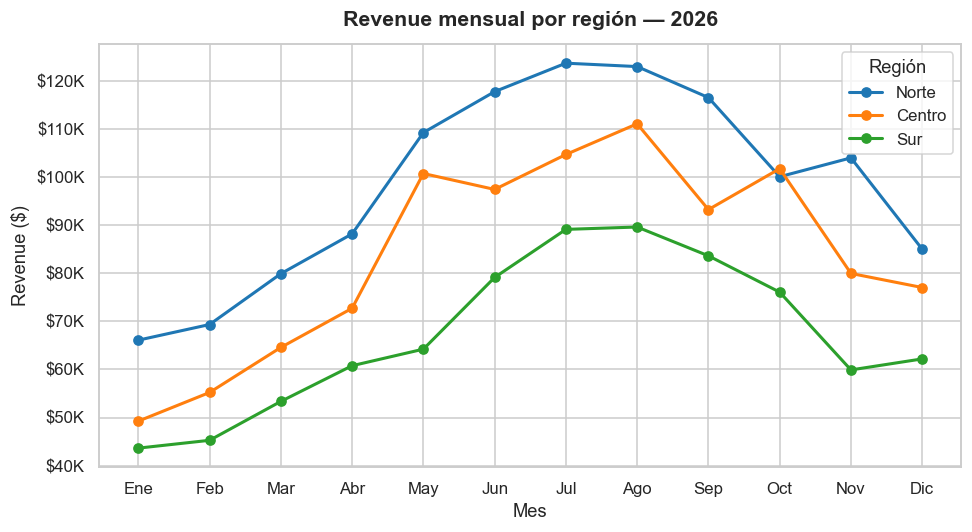

In [15]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = rev_mes_region[rev_mes_region['Region'] == region]
    plt.plot(MESES, datos['Revenue'], marker='o', linewidth=2, label=region)

plt.title('Revenue mensual por región — 2026', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

In [ ]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=rev_mes_region, x='MesNum', y='Revenue',
             hue='Region', marker='o', linewidth=2)

plt.title('Revenue mensual por región — 2024', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Revenue ($)')
plt.xticks(ticks=range(1, 13), labels=MESES)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

---
## 2. Bar Plot — Comparación entre categorías

**Dato:** revenue total por producto.

In [17]:
rev_prod = (
    df.groupby('Producto')['Revenue']
    .sum().reset_index()
    .sort_values('Revenue', ascending=False)
)

#### 🔵 Matplotlib

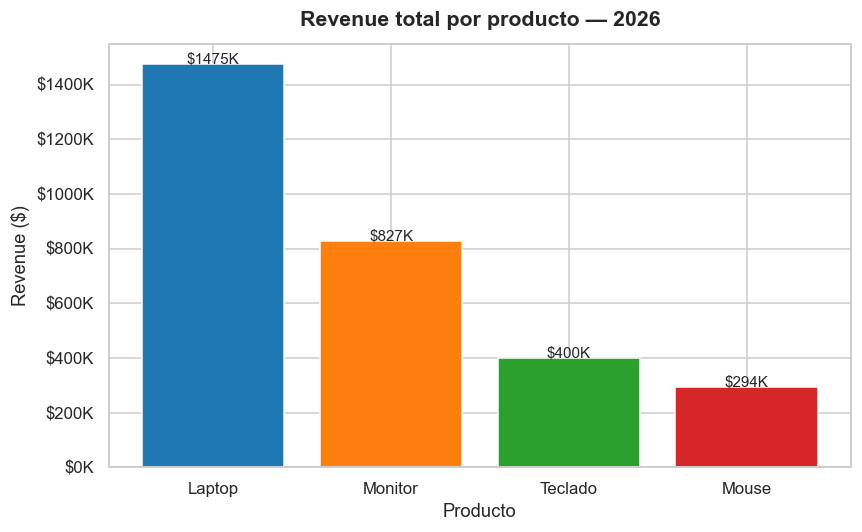

In [18]:
plt.figure(figsize=(8, 5))
bars = plt.bar(rev_prod['Producto'], rev_prod['Revenue'],
               color=sns.color_palette('tab10', len(rev_prod)),
               edgecolor='white')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 4000,
             f'${h/1000:.0f}K', ha='center', fontsize=10)

plt.title('Revenue total por producto — 2026', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rev_prod, x='Producto', y='Revenue',
            hue='Producto', legend=False)

plt.title('Revenue total por producto — 2024', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

---
## 3. Histogram — Distribución de una variable

**Dato:** distribución del revenue por transacción.

#### 🔵 Matplotlib

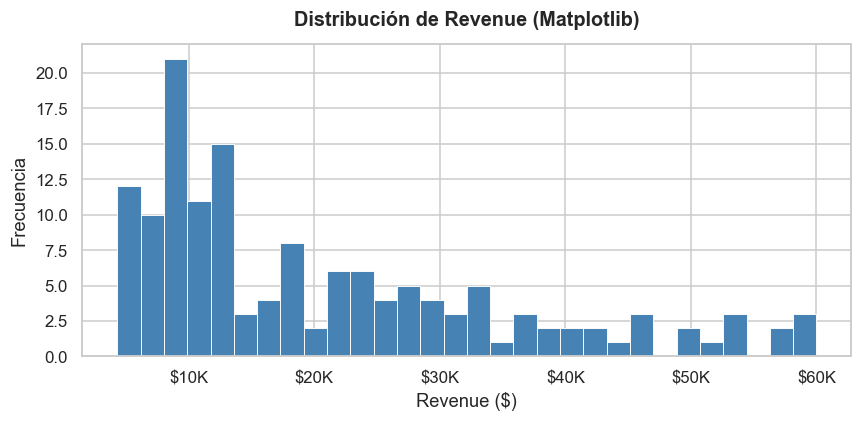

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(df['Revenue'], bins=30, color='steelblue',
         edgecolor='white', linewidth=0.6)

plt.title('Distribución de Revenue (Matplotlib)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

> `kde=True` agrega la curva de densidad (KDE) sin código extra.

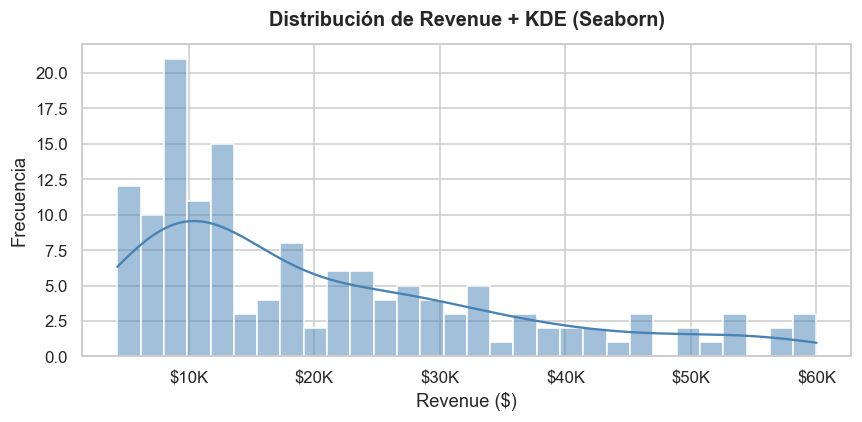

Media:        $20,809
Mediana:      $15,600
Asimetría G1: 1.0611


In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Revenue'], bins=30, kde=True, color='steelblue')

plt.title('Distribución de Revenue + KDE (Seaborn)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print(f"Media:        ${df['Revenue'].mean():,.0f}")
print(f"Mediana:      ${df['Revenue'].median():,.0f}")
print(f"Asimetría G1: {df['Revenue'].skew():.4f}")

---
## 4. Box Plot — Distribución + outliers

**Dato:** distribución del revenue por región.

#### 🔵 Matplotlib

C:\Users\cmarc\AppData\Local\Temp\ipykernel_22384\2858168402.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(datos_box, labels=REGIONES, patch_artist=True)


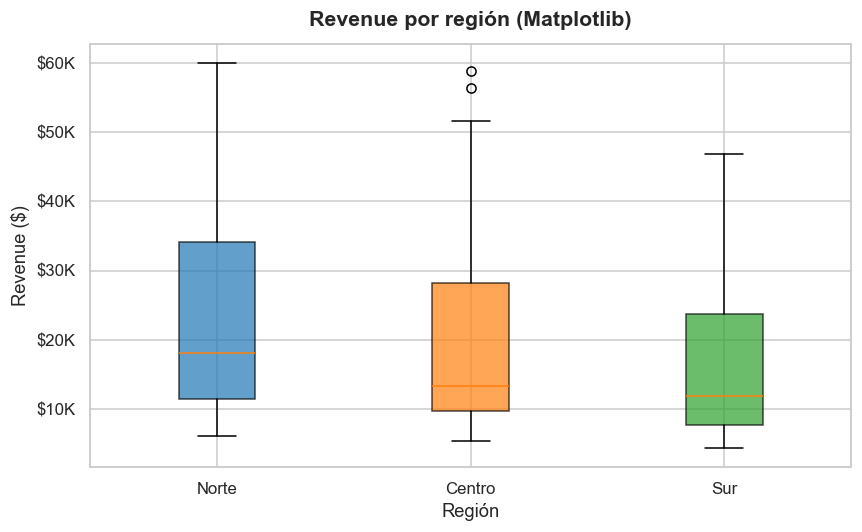

In [6]:
datos_box = [df[df['Region'] == r]['Revenue'].values for r in REGIONES]

plt.figure(figsize=(8, 5))
bp = plt.boxplot(datos_box, labels=REGIONES, patch_artist=True)

colores = sns.color_palette('tab10', len(REGIONES))
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Revenue por región (Matplotlib)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Región')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

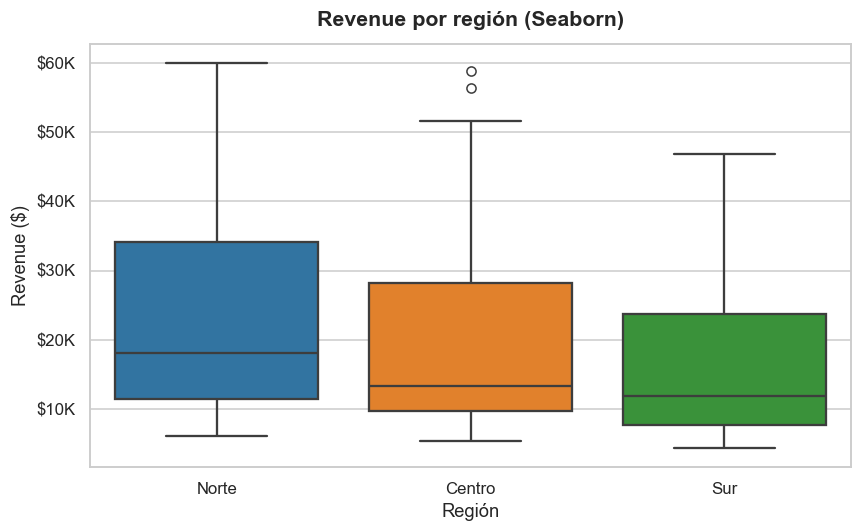

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Region', y='Revenue',
            hue='Region', legend=False, linewidth=1.5)

plt.title('Revenue por región (Seaborn)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Región')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

---
## 5. Violin Plot — Distribución con forma

**Dato:** distribución del revenue por producto.

#### 🔵 Matplotlib

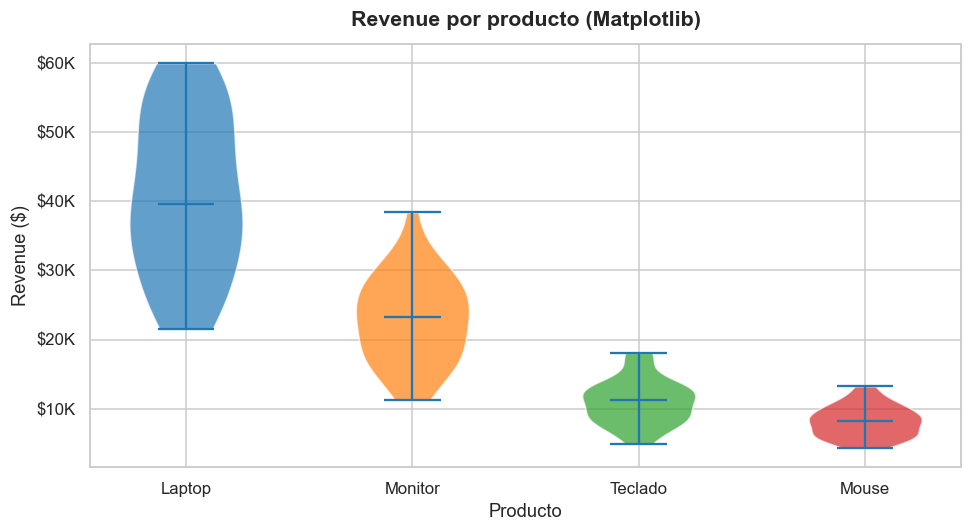

In [8]:
datos_violin = [df[df['Producto'] == p]['Revenue'].values for p in PRODUCTOS]

plt.figure(figsize=(9, 5))
parts = plt.violinplot(datos_violin, positions=range(1, len(PRODUCTOS) + 1),
                       showmedians=True)

colores = sns.color_palette('tab10', len(PRODUCTOS))
for pc, color in zip(parts['bodies'], colores):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

plt.xticks(range(1, len(PRODUCTOS) + 1), PRODUCTOS)
plt.title('Revenue por producto (Matplotlib)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

In [ ]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='Producto', y='Revenue',
               hue='Producto', legend=False,
               inner='quartile', linewidth=1.2)

plt.title('Revenue por producto (Seaborn)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

---
## 6. Scatter Plot — Relación entre dos variables

**Dato:** cantidad vendida vs revenue, coloreado por región.

#### 🔵 Matplotlib

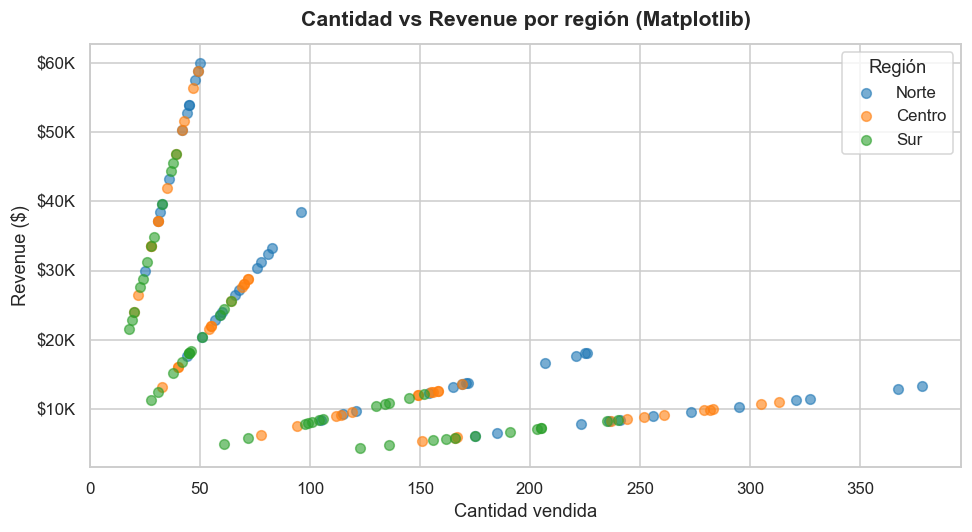

In [9]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = df[df['Region'] == region]
    plt.scatter(datos['Cantidad'], datos['Revenue'],
                label=region, alpha=0.6, s=40)

plt.title('Cantidad vs Revenue por región (Matplotlib)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Cantidad vendida')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Cantidad', y='Revenue',
                hue='Region', alpha=0.6, s=40)

plt.title('Cantidad vs Revenue por región (Seaborn)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Cantidad vendida')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

---
## 7. Heatmap — Datos en grilla

**Dato:** revenue mensual por producto (pivot mes × producto).

In [ ]:
pivot = (
    df.groupby(['Mes', 'Producto'])['Revenue']
    .sum().unstack().reindex(MESES)
)

#### 🔵 Matplotlib

In [ ]:
plt.figure(figsize=(9, 6))
img = plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(img, label='Revenue ($)')

plt.xticks(range(len(PRODUCTOS)), PRODUCTOS)
plt.yticks(range(len(MESES)), MESES)
plt.title('Revenue mensual por producto (Matplotlib)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

> `annot=True` agrega el valor numérico en cada celda automáticamente.

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'label': 'Revenue ($)'})

plt.title('Revenue mensual por producto (Seaborn)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

---
## 8. Pair Plot — Solo Seaborn

Genera scatter plots entre todos los pares de variables numéricas. No tiene equivalente directo en Matplotlib puro.

In [ ]:
g = sns.pairplot(
    df[['Cantidad', 'Precio', 'Revenue', 'Region']],
    hue='Region',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 25},
    height=2.5
)
g.figure.suptitle('Pair plot — variables de ventas', y=1.02,
                  fontsize=14, fontweight='bold')
plt.show()

---
## 9. Dashboards — Solo Seaborn

Múltiples gráficos en una figura con `plt.subplots()`. Acá sí necesitamos el eje explícito (`ax`) para indicarle a seaborn dónde dibujar cada gráfico.

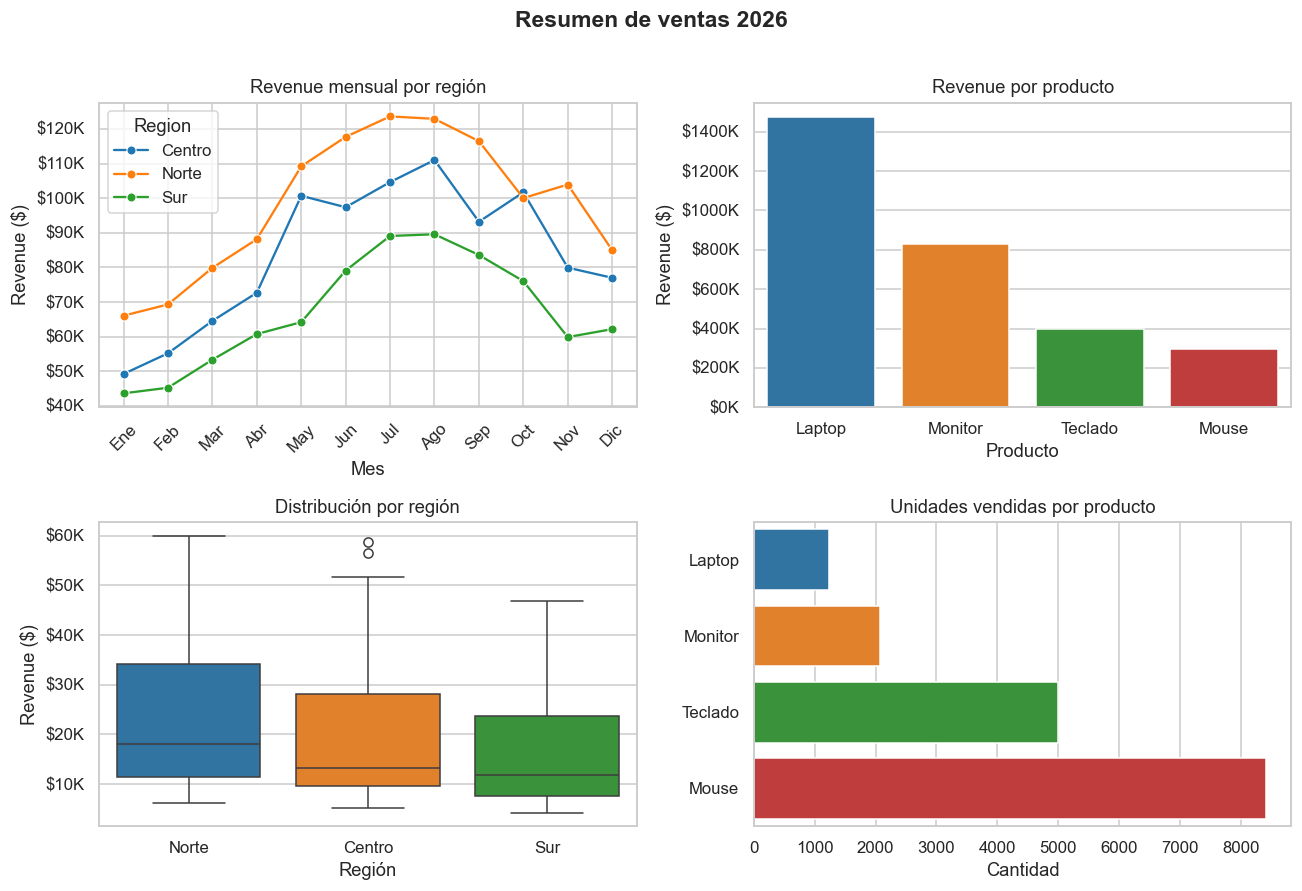

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Resumen de ventas 2026', fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Revenue mensual ──────────────────────────────────────
rev_mes_region = (
    df.groupby(['MesNum', 'Region'])['Revenue'].sum().reset_index()
)
sns.lineplot(data=rev_mes_region, x='MesNum', y='Revenue',
             hue='Region', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Revenue mensual por región')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(MESES, rotation=45)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 2: Revenue por producto ────────────────────────────────
rev_prod = df.groupby('Producto')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)
sns.barplot(data=rev_prod, x='Producto', y='Revenue',
            hue='Producto', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Revenue por producto')
axes[0, 1].set_xlabel('Producto')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 3: Box plot por región ──────────────────────────────────
sns.boxplot(data=df, x='Region', y='Revenue',
            hue='Region', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribución por región')
axes[1, 0].set_xlabel('Región')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 4: Cantidad por producto ───────────────────────────────
cant_prod = df.groupby('Producto')['Cantidad'].sum().reset_index().sort_values('Cantidad')
sns.barplot(data=cant_prod, x='Cantidad', y='Producto',
            hue='Producto', legend=False,
            orient='h', ax=axes[1, 1])
axes[1, 1].set_title('Unidades vendidas por producto')
axes[1, 1].set_xlabel('Cantidad')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

---
## 10. Widgets interactivos — `ipywidgets`

`ipywidgets` permite agregar controles interactivos (sliders, dropdowns, botones) directamente en la notebook.

```bash
pip install ipywidgets
```

El decorador `@interact` conecta automáticamente el widget con la función: cada vez que el usuario mueve el control, la función se vuelve a ejecutar y el gráfico se actualiza.

In [11]:
import ipywidgets as widgets
from ipywidgets import interact
print('ipywidgets listo')

ipywidgets listo


### 🎚️ Slider — Filtrar rango de meses

Un `IntRangeSlider` permite seleccionar un rango numérico con dos manijas.
El gráfico muestra el revenue mensual solo para el rango elegido.

In [ ]:
def grafico_slider(rango_meses):
    mes_ini, mes_fin = rango_meses

    datos = (
        df[(df['MesNum'] >= mes_ini) & (df['MesNum'] <= mes_fin)]
        .groupby(['MesNum', 'Region'])['Revenue']
        .sum().reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=datos, x='MesNum', y='Revenue',
                 hue='Region', marker='o')

    plt.title(f'Revenue mensual — meses {MESES[mes_ini-1]} a {MESES[mes_fin-1]}',
              fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Mes')
    plt.ylabel('Revenue ($)')
    plt.xticks(
        ticks=range(mes_ini, mes_fin + 1),
        labels=MESES[mes_ini - 1: mes_fin]
    )
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    )
    plt.legend(title='Región')
    plt.tight_layout()
    plt.show()


slider_meses = widgets.IntRangeSlider(
    value=[1, 12],
    min=1, max=12, step=1,
    description='Meses:',
    continuous_update=False,
    layout=widgets.Layout(width='500px'),
)

interact(grafico_slider, rango_meses=slider_meses)


interactive(children=(IntRangeSlider(value=(1, 12), continuous_update=False, description='Meses:', layout=Layo…

<function __main__.grafico_slider(rango_meses)>

### 📋 Dropdown — Seleccionar región

Un `Dropdown` permite elegir un valor de una lista.
El gráfico muestra el revenue por producto para la región seleccionada.

In [13]:
def grafico_dropdown(region):
    datos = (
        df[df['Region'] == region]
        .groupby(['MesNum', 'Producto'])['Revenue']
        .sum().reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=datos, x='MesNum', y='Revenue',
                 hue='Producto', marker='o')

    plt.title(f'Revenue mensual por producto — Región {region}',
              fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Mes')
    plt.ylabel('Revenue ($)')
    plt.xticks(ticks=range(1, 13), labels=MESES)
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    )
    plt.legend(title='Producto')
    plt.tight_layout()
    plt.show()


dropdown_region = widgets.Dropdown(
    options=REGIONES,
    value='Norte',
    description='Región:',
)

interact(grafico_dropdown, region=dropdown_region)


interactive(children=(Dropdown(description='Región:', options=('Norte', 'Centro', 'Sur'), value='Norte'), Outp…

<function __main__.grafico_dropdown(region)>

### 🎚️ + 📋 Combinado — Slider y Dropdown juntos

Se pueden combinar múltiples widgets en una misma función.
Acá filtramos por región (dropdown) y tipo de gráfico (dropdown) simultáneamente.

In [14]:
def grafico_combinado(region, top_n):
    top_productos = (
        df[df['Region'] == region]
        .groupby('Producto')['Revenue']
        .sum()
        .nlargest(top_n)
        .index.tolist()
    )

    datos = (
        df[(df['Region'] == region) & (df['Producto'].isin(top_productos))]
        .groupby(['MesNum', 'Producto'])['Revenue']
        .sum().reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=datos, x='MesNum', y='Revenue',
                 hue='Producto', marker='o')

    plt.title(f'Top {top_n} productos — Región {region}',
              fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Mes')
    plt.ylabel('Revenue ($)')
    plt.xticks(ticks=range(1, 13), labels=MESES)
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    )
    plt.legend(title='Producto')
    plt.tight_layout()
    plt.show()


dropdown_region2 = widgets.Dropdown(
    options=REGIONES,
    value='Norte',
    description='Región:',
)

slider_top_n = widgets.IntSlider(
    value=4,
    min=1, max=4, step=1,
    description='Top N productos:',
    continuous_update=False,
    layout=widgets.Layout(width='400px'),
)

interact(grafico_combinado, region=dropdown_region2, top_n=slider_top_n)


interactive(children=(Dropdown(description='Región:', options=('Norte', 'Centro', 'Sur'), value='Norte'), IntS…

<function __main__.grafico_combinado(region, top_n)>

---
## ✏️ Ejercicios

**Ejercicio 1.** Repetí el line plot de la sección 1 pero mostrando **cantidad vendida** en lugar de revenue. Hacelo en ambas librerías.

**Ejercicio 2.** Hacé un bar plot horizontal con el revenue por región. Hacelo en ambas librerías.

**Ejercicio 3.** En el scatter plot (sección 6), reemplazá el color por producto en lugar de región. ¿Qué patrón aparece?

**Ejercicio 4.** Creá un heatmap con el pivot de **cantidad** por región y mes (filas=Región, columnas=Mes).

**Ejercicio 5.** Extendé el dashboard de la sección 9 agregando un quinto panel: violin plot de revenue por producto.

In [ ]:
# Ejercicio 1


In [ ]:
# Ejercicio 2


In [ ]:
# Ejercicio 3


In [ ]:
# Ejercicio 4


In [ ]:
# Ejercicio 5
